In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels
import geopandas as gpd
#import geodatasets
sns.set_theme(style="whitegrid")

In [4]:
df = pd.read_csv("../data/processed/hdb_resale_cleaned.csv")
df.head()

,resale_price_ht,sale_date,town,flat_type,storey_midpoint,floor_area_sqm,flat_model,remaining_lease_months,transaction_year,transaction_month
0,2.32,2017-01-01,ANG MO KIO,2 ROOM,11.0,44.0,Improved,736,2017,January
1,2.50,2017-01-01,ANG MO KIO,3 ROOM,2.0,67.0,New Generation,727,2017,January
2,2.62,2017-01-01,ANG MO KIO,3 ROOM,2.0,67.0,New Generation,749,2017,January
3,2.65,2017-01-01,ANG MO KIO,3 ROOM,5.0,68.0,New Generation,745,2017,January
4,2.65,2017-01-01,ANG MO KIO,3 ROOM,2.0,67.0,New Generation,749,2017,January


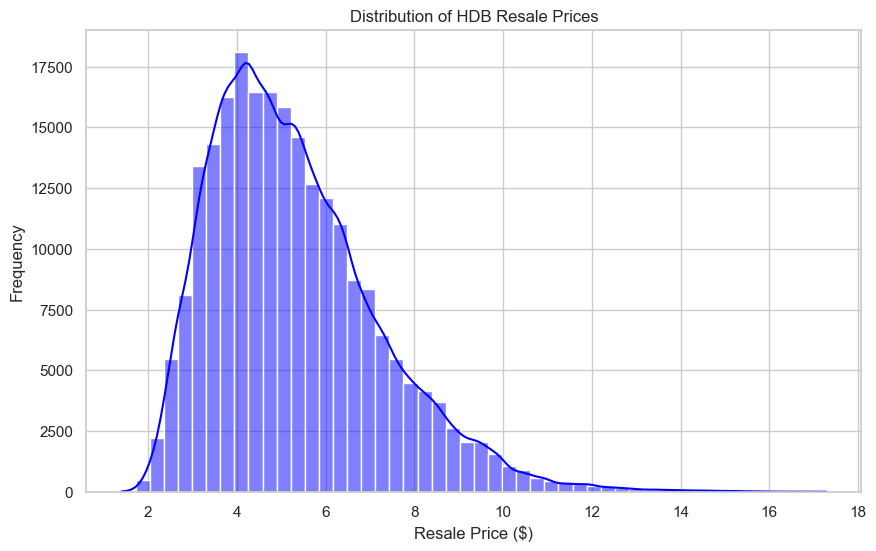

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['resale_price_ht'], bins=50, kde=True, color='blue')
plt.title('Distribution of HDB Resale Prices')
plt.xlabel('Resale Price ($)')
plt.ylabel('Frequency')
plt.show()

# Numerical (continuous) variables
### `floor_area_sqm`, `remaining_lease_months`

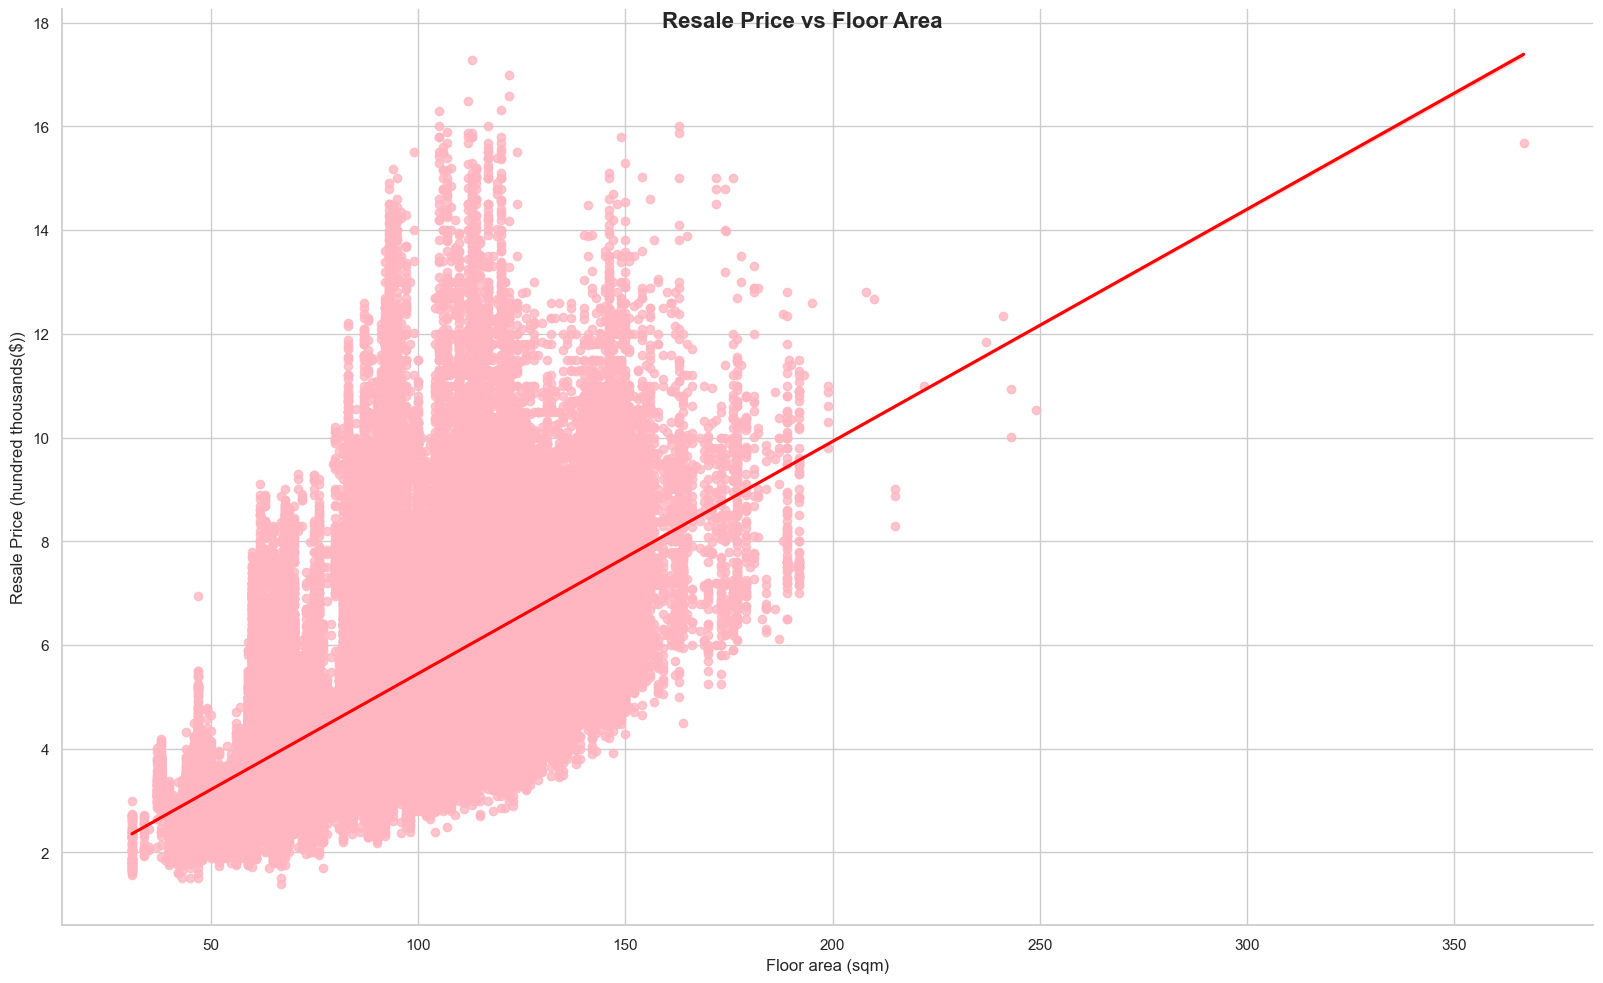

In [6]:
# floor_area_sqm
floor_area_sqm_plot = sns.lmplot(df, x = 'floor_area_sqm', y = 'resale_price_ht', line_kws = {'color': 'red'}, height = 10, aspect = 1.618, scatter_kws = {'color': 'lightpink'})

floor_area_sqm_plot.set_axis_labels('Floor area (sqm)', 'Resale Price (hundred thousands($))')
floor_area_sqm_plot.figure.suptitle('Resale Price vs Floor Area', fontsize = 16, fontweight = 'bold')
plt.show()


KeyboardInterrupt: 

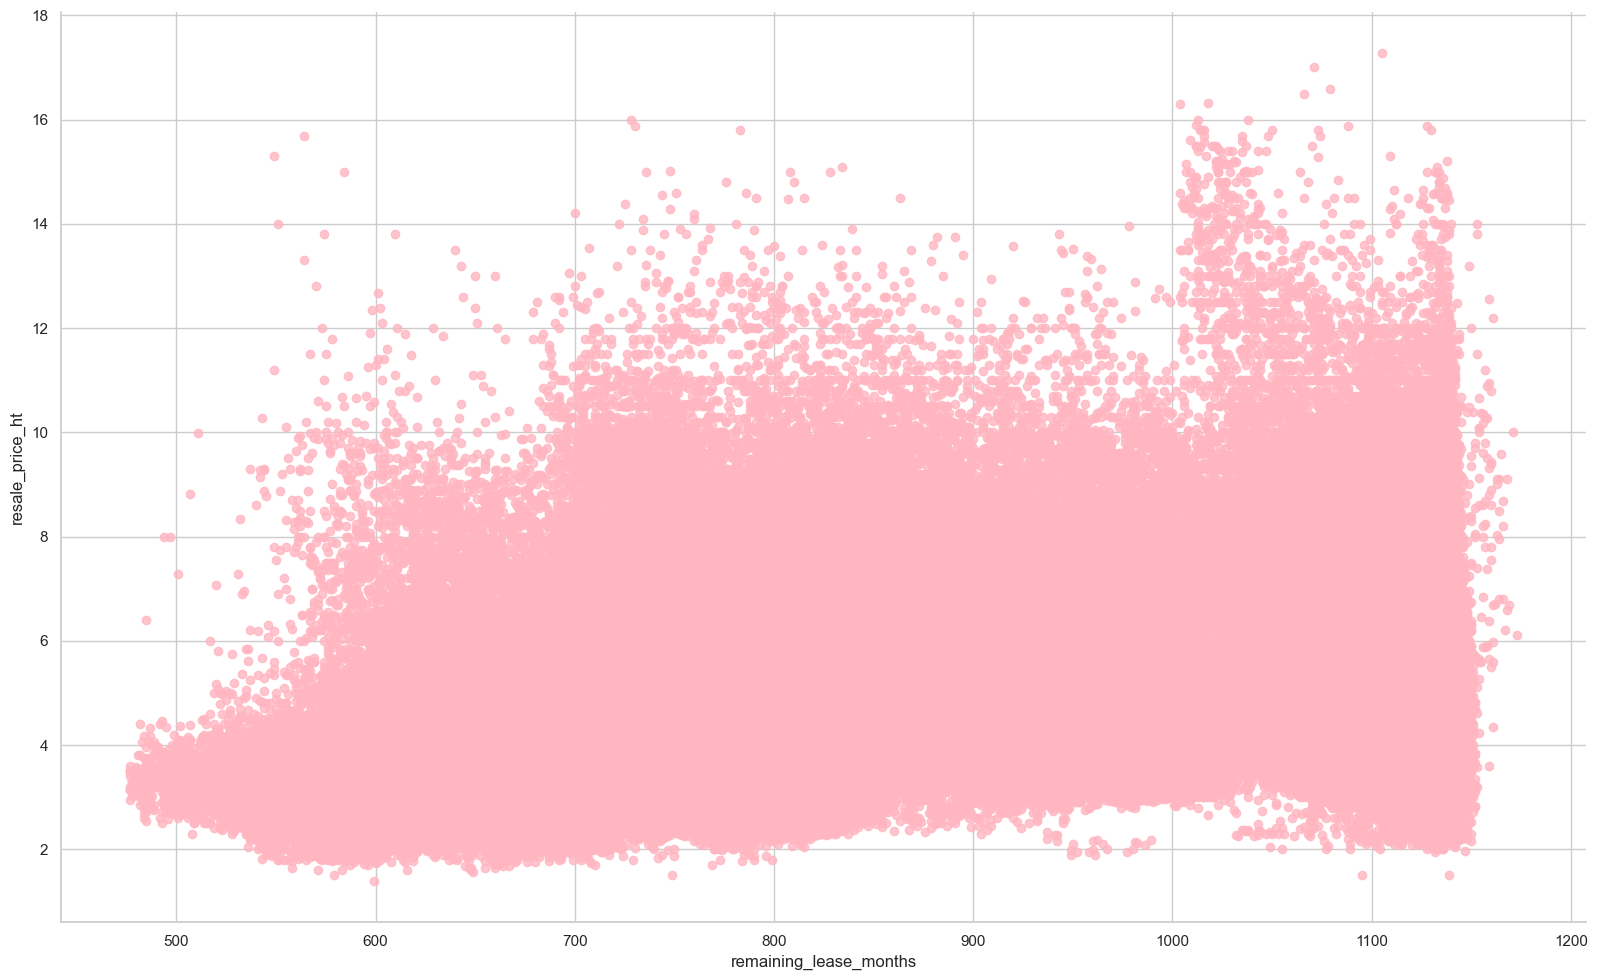

In [7]:
# remaining_lease_months
remaining_lease_months_plot = sns.lmplot(df, x = 'remaining_lease_months', y = 'resale_price_ht', line_kws = {'color': 'red'}, height = 10, aspect = 1.618, scatter_kws = {'color': 'lightpink'})

remaining_lease_months_plot.set_axis_labels('Remaining Lease (months)', 'Resale Price (hundred thousands ($))')
remaining_lease_months_plot.figure.suptitle('Resale Price vs Remaining Lease', fontsize = 16, fontweight = 'bold')
plt.show()


# Numerical (discrete) variables
### `storey_midpoint`

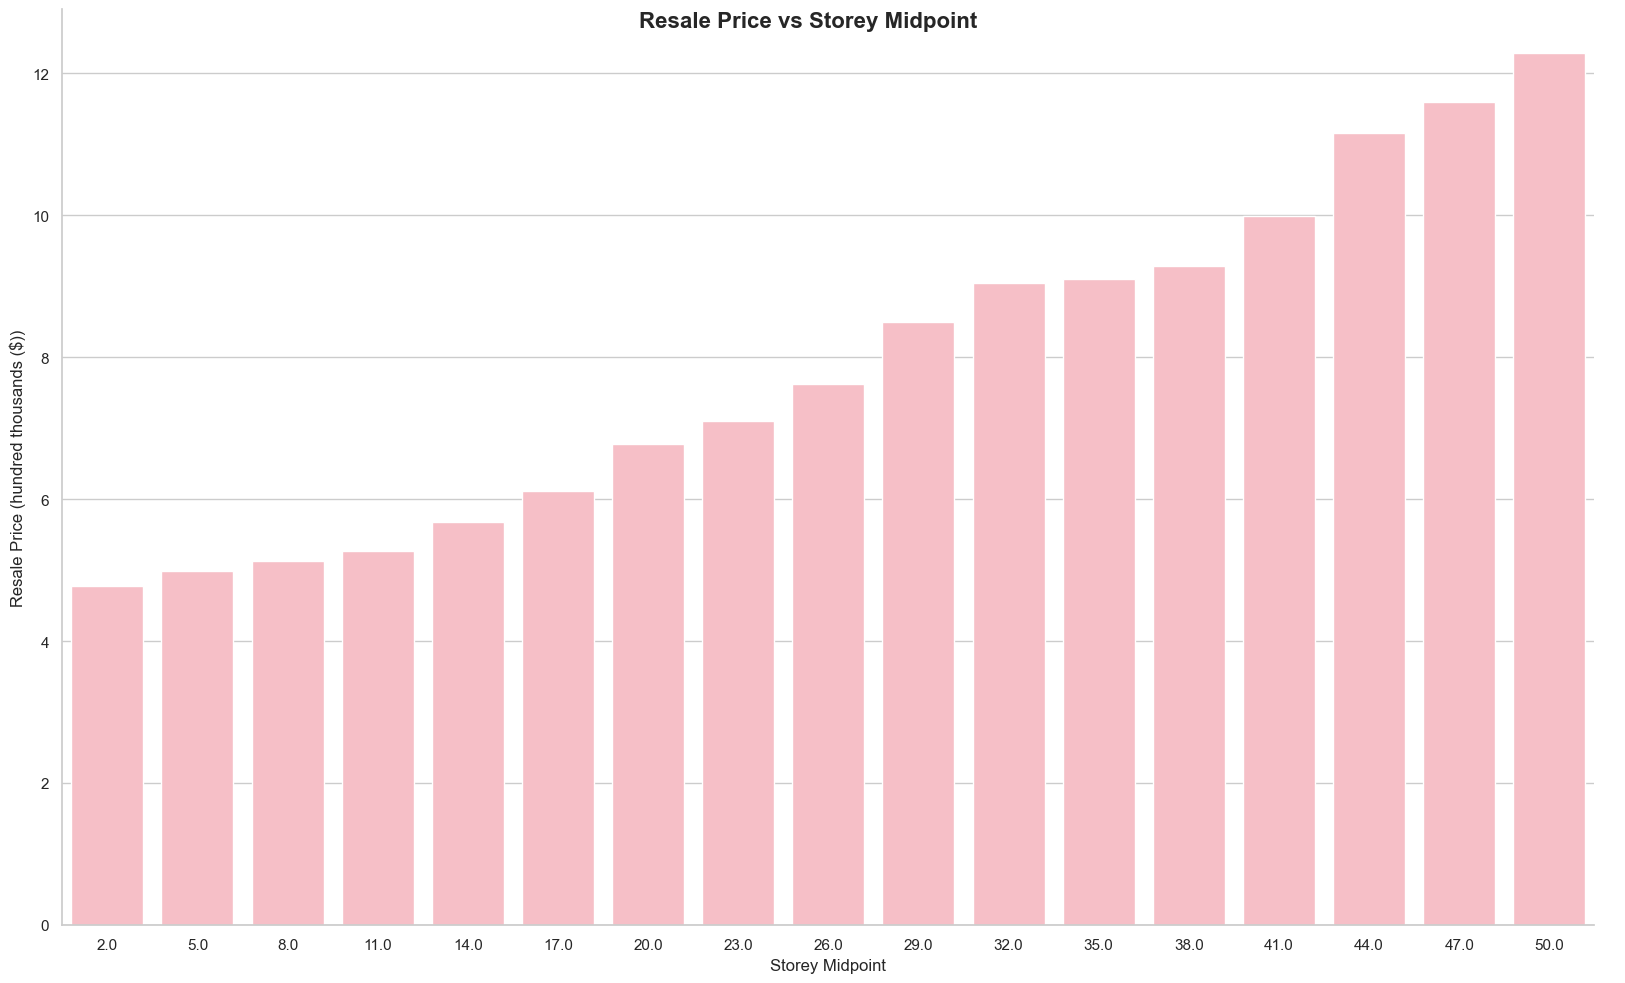

In [ ]:
# storey_midpoint
storey_midpoint_plot = sns.catplot(df, kind = 'bar', x = 'storey_midpoint', y = 'resale_price_ht', height = 10, aspect = 1.618, errorbar = None, color = 'lightpink')

storey_midpoint_plot.set_axis_labels('Storey Midpoint', 'Resale Price (hundred thousands ($))')
storey_midpoint_plot.figure.suptitle('Resale Price vs Storey Midpoint', fontsize = 16, fontweight = 'bold')
plt.show()


# Categorical variables
### `town`, `flat_type`, `flat_model`, `transaction_year`, `transaction_month` 

,town,resale_price_ht
0,ANG MO KIO,4.850410
1,BEDOK,4.845098
2,BISHAN,7.138454
3,BUKIT BATOK,5.071505
4,BUKIT MERAH,6.412615


In [30]:
map_line = gpd.read_file('../data/raw/SingaporeMap_Line.json')
map_poly = gpd.read_file('../data/raw/SingaporeMap_Polygon.json')
sg_map=gpd.read_file('../data/raw/SingaporeMapTowns.geojson')

In [38]:

unique_towns = df['town'].unique().tolist()
unique_towns.sort()

print("town names df:")
for town in unique_towns:
    print(town)

town names df:
ANG MO KIO
BEDOK
BISHAN
BUKIT BATOK
BUKIT MERAH
BUKIT PANJANG
BUKIT TIMAH
CENTRAL AREA
CHOA CHU KANG
CLEMENTI
GEYLANG
HOUGANG
JURONG EAST
JURONG WEST
KALLANG/WHAMPOA
MARINE PARADE
PASIR RIS
PUNGGOL
QUEENSTOWN
SEMBAWANG
SENGKANG
SERANGOON
TAMPINES
TOA PAYOH
WOODLANDS
YISHUN


In [37]:
town_names = sg_map['PLN_AREA_N'].unique().tolist()
town_names.sort()
print("town names map:")
for town in town_names:
    print(town)

town names map:
ANG MO KIO
BEDOK
BISHAN
BOON LAY
BUKIT BATOK
BUKIT MERAH
BUKIT PANJANG
BUKIT TIMAH
CENTRAL WATER CATCHMENT
CHANGI
CHANGI BAY
CHOA CHU KANG
CLEMENTI
DOWNTOWN CORE
GEYLANG
HOUGANG
JURONG EAST
JURONG WEST
KALLANG
LIM CHU KANG
MANDAI
MARINA EAST
MARINA SOUTH
MARINE PARADE
MUSEUM
NEWTON
NORTH-EASTERN ISLANDS
NOVENA
ORCHARD
OUTRAM
PASIR RIS
PAYA LEBAR
PIONEER
PUNGGOL
QUEENSTOWN
RIVER VALLEY
ROCHOR
SELETAR
SEMBAWANG
SENGKANG
SERANGOON
SIMPANG
SINGAPORE RIVER
SOUTHERN ISLANDS
STRAITS VIEW
SUNGEI KADUT
TAMPINES
TANGLIN
TENGAH
TOA PAYOH
TUAS
WESTERN ISLANDS
WESTERN WATER CATCHMENT
WOODLANDS
YISHUN


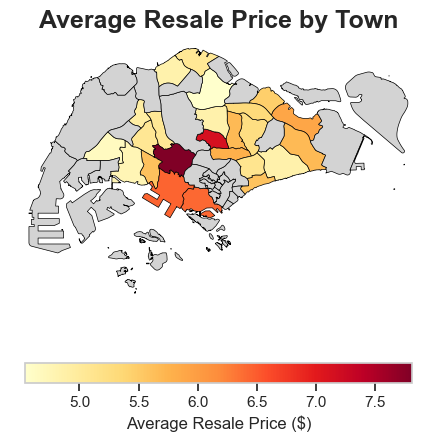

In [ ]:


price_by_town = df.groupby('town')['resale_price_ht'].mean().reset_index()
price_by_town['town'] = price_by_town['town'].str.upper()
merged_map = sg_map.merge(price_by_town, left_on='PLN_AREA_N', right_on='town', how='left')
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
merged_map.plot(column='resale_price_ht', 
                ax=ax, 
                cmap='YlOrRd',    
                linewidth=0.5, 
                edgecolor='black',
                legend=True,
                legend_kwds={'label': "Average Resale Price ($)", 
                             'orientation': "horizontal",
                             'shrink': 0.5},
                missing_kwds={'color': 'lightgrey', 
                              'label': 'No Data'})


plt.title('Average Resale Price by Town', fontsize=18, fontweight='bold')
plt.axis('off')

plt.show()

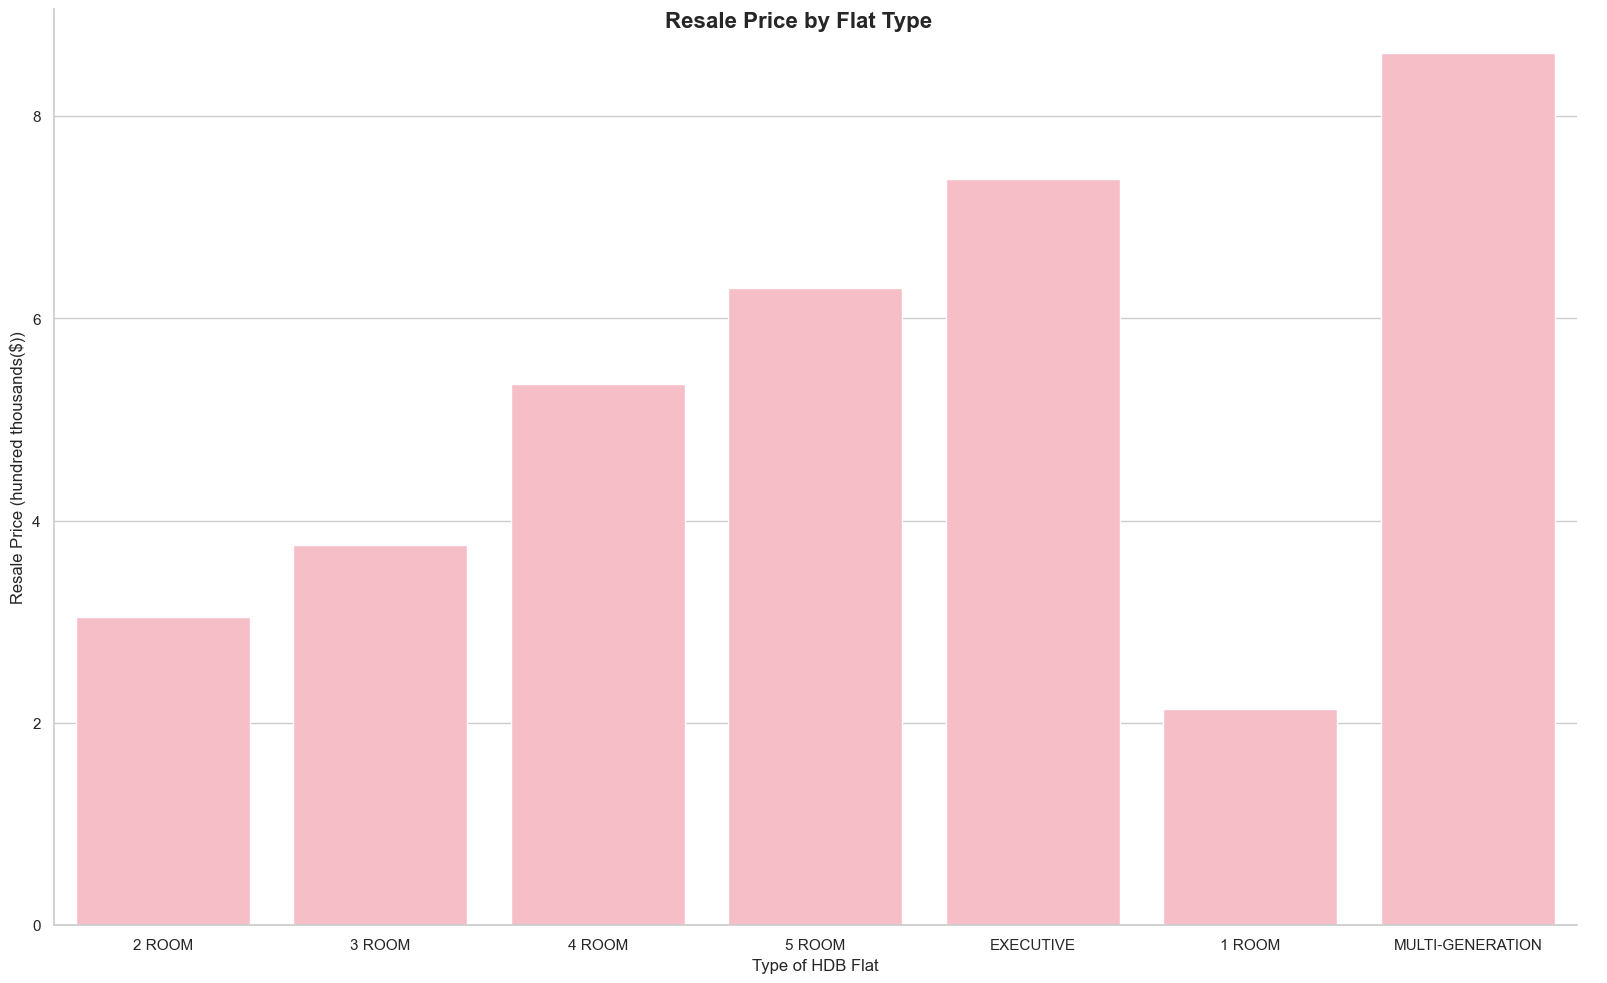

In [ ]:
# Flat_type_plot
flat_type_plot = sns.catplot(data=df, kind='bar', x='flat_type', y='resale_price_ht', height=10, aspect=1.6,errorbar= None,color='lightpink')


flat_type_plot.set(
   
    xlabel="Type of HDB Flat",
    ylabel="Resale Price (hundred thousands($))"
)
flat_type_plot.figure.suptitle("Resale Price by Flat Type", fontsize=16,fontweight='bold')
plt.show()

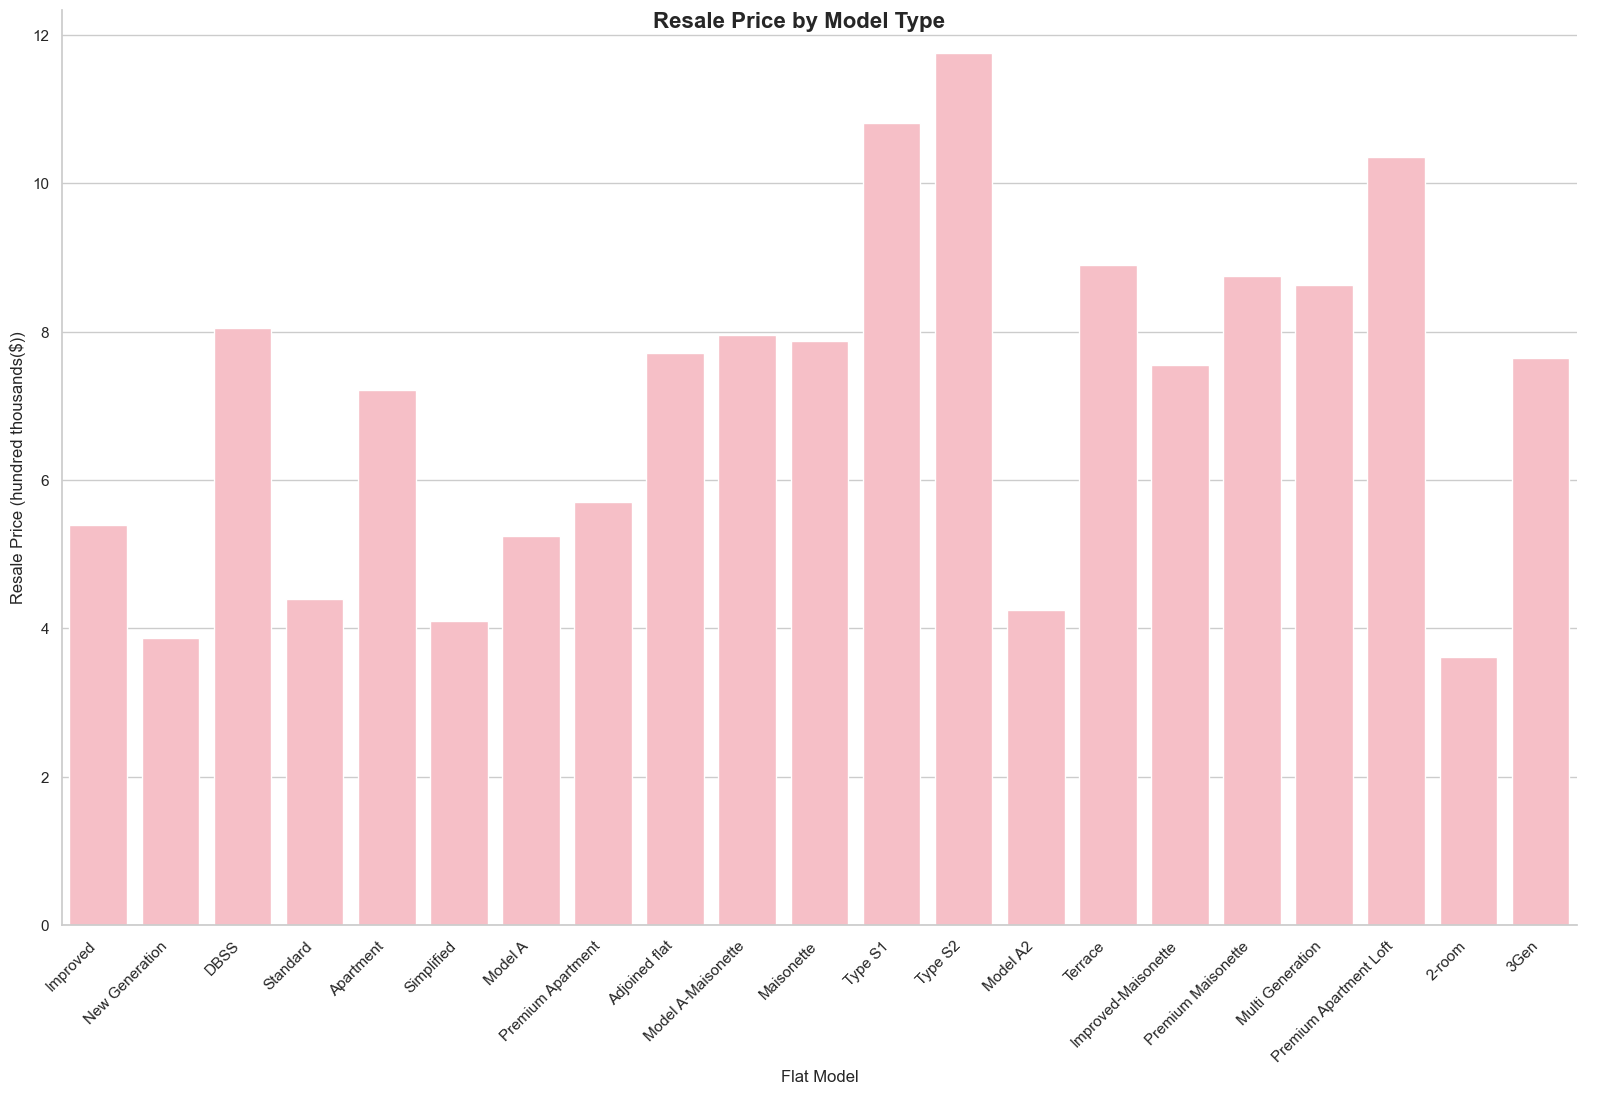

In [ ]:
#Flat_model_plot
flat_model_plot= sns.catplot(data=df, kind='bar', x='flat_model', y='resale_price_ht', height=10, aspect=1.6,errorbar= None,color='lightpink')


flat_model_plot.set(
    
    xlabel="Flat Model",
    ylabel="Resale Price (hundred thousands($))"
)
flat_model_plot.figure.suptitle("Resale Price by Model Type", fontsize=16,fontweight='bold')
flat_model_plot.set_xticklabels(rotation=45, ha='right')
flat_model_plot.ax.ticklabel_format(style='plain', axis='y')
plt.show()


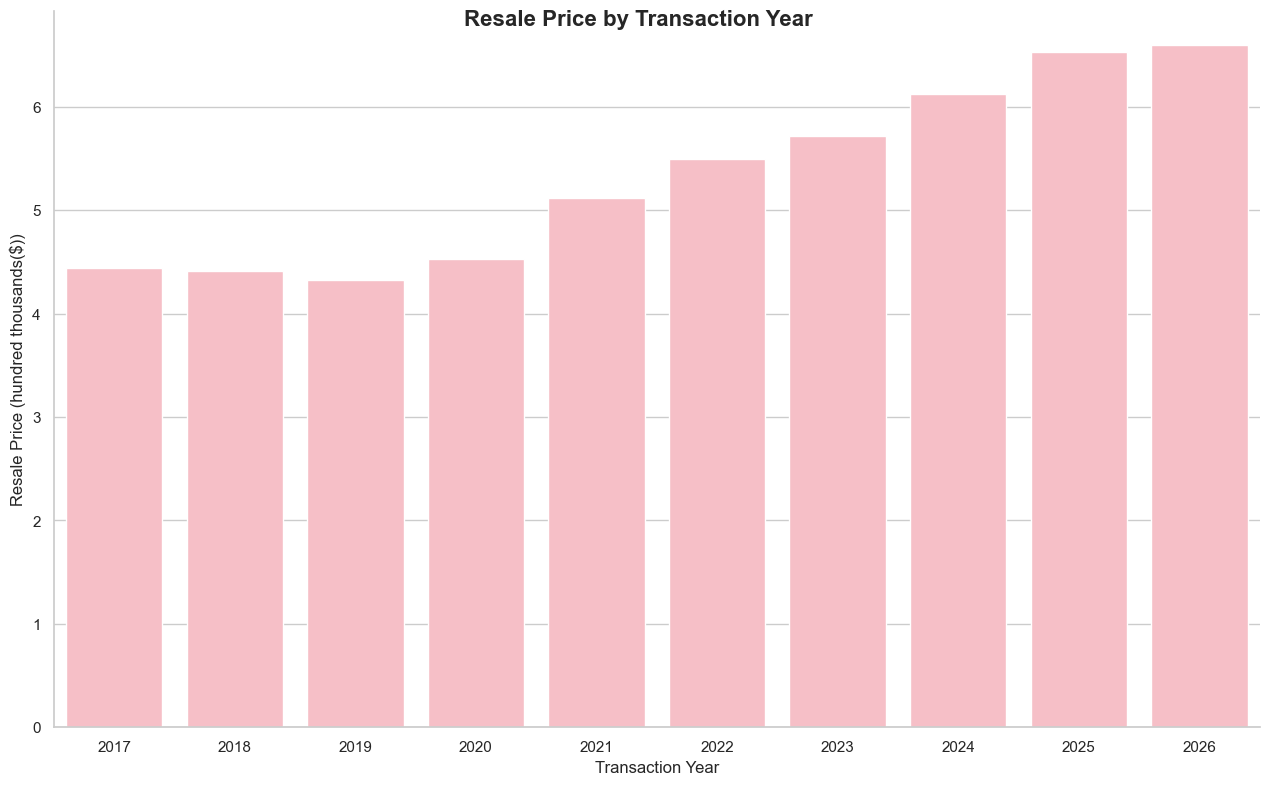

In [ ]:
#Transaction_year_plot
transaction_year_plot = sns.catplot(data=df, kind='bar', x='transaction_year', y='resale_price_ht', height=8, aspect=1.6,errorbar= None,color='lightpink')


transaction_year_plot.set(
   
    xlabel="Transaction Year",
    ylabel="Resale Price (hundred thousands($))"
)
transaction_year_plot.figure.suptitle("Resale Price by Transaction Year", fontsize=16,fontweight='bold')
plt.show()

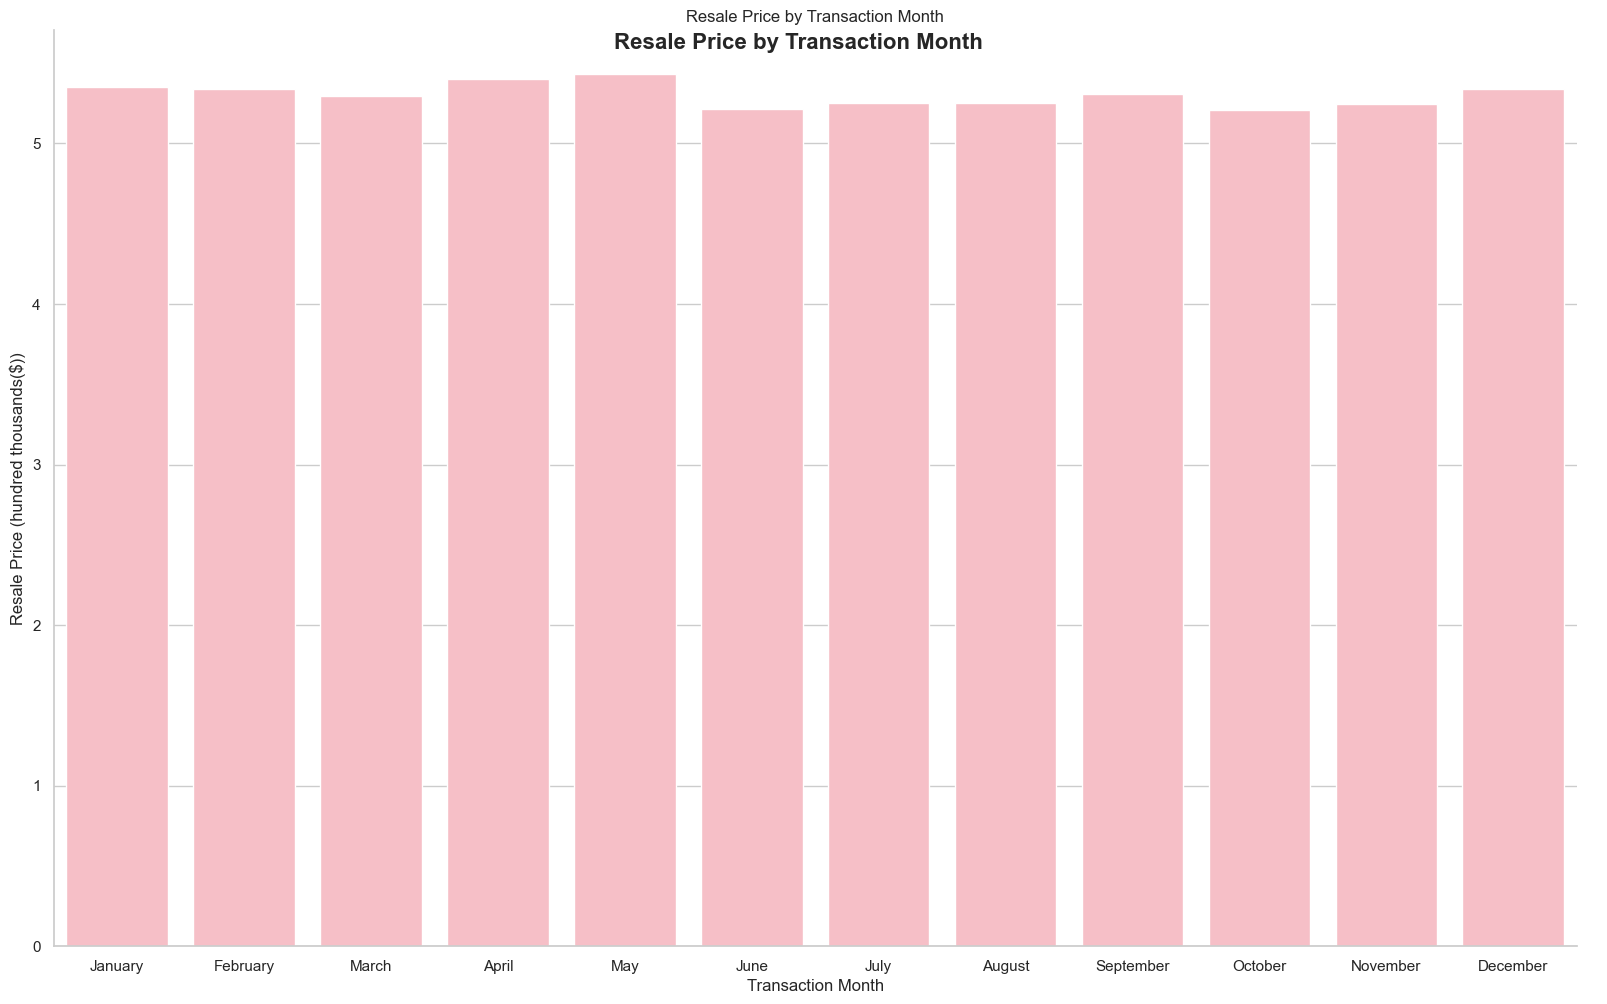

In [ ]:
#Transaction_month_plot
transaction_month_plot = sns.catplot(data=df, kind='bar', x='transaction_month', y='resale_price_ht', height=10, aspect=1.6,errorbar= None,color='lightpink')


transaction_month_plot.set(
    title="Resale Price by Transaction Month",
    xlabel="Transaction Month",
    ylabel="Resale Price (hundred thousands($))"
)
transaction_month_plot.figure.suptitle("Resale Price by Transaction Month", fontsize=16,fontweight='bold')
plt.show()